# Proyek Analisis Data: E-Commerce-Public-Dataset
- **Nama:** Brahmana Saifullah Setya Budi
- **Email:** brahmanabudi09@gmail.com
- **ID Dicoding:** CDCC180D6Y1560

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi revenue tertinggi dan terendah selama periode 2016-2017?
- **Pertanyaan 2:** Bagaimana tren jumlah order dan total revenue secara bulanan selama periode 2016-2018?
- ...

## Import Semua Packages/Library yang Digunakan

In [3]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [4]:
zip_path = '/content/drive/MyDrive/Projek Analisis Data/E-commerce-public-dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Projek Analisis Data')

print("Isi folder:")
print(os.listdir('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset'))

Isi folder:
['customers_dataset.csv', 'geolocation_dataset.csv', 'New Text Document.txt', 'order_items_dataset.csv', 'order_payments_dataset.csv', 'order_reviews_dataset.csv', 'orders_dataset.csv', 'product_category_name_translation.csv', 'products_dataset.csv', 'sellers_dataset.csv']


## Data Wrangling

### Gathering Data

#### Load df ...

In [5]:
customers = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/customers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/geolocation_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/order_items_dataset.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/order_reviews_dataset.csv')
orders = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/orders_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/products_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/sellers_dataset.csv')
category_translation = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/product_category_name_translation.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:** (Opsional)
- Dataset yang digunakan mencakup informasi transaksi, produk, pembayaran, dan pelanggan
- Penggabungan dataset memungkinkan untuk dilakukan analisis secara menyeluruh terhadap performa penjualan

### Assessing Data

#### Identifying ... problem

In [6]:
def assess_data(df, name):
    print(f"\n===== {name} =====")
    print(df.info())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicate Data:", df.duplicated().sum())

assess_data(orders, "Orders")
assess_data(order_items, "Order Items")
assess_data(products, "Products")
assess_data(order_payments, "Payments")


===== Orders =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing Values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date 

**Steps to Take:**
- Untuk Missing Value pada dataset orders dilakukan pengubahan kolom menjadi tipe dateTime, lalu mengisi missing value menggunakan median dan menghapus data sebagai jalur alternatif
- Untuk Missing Value pada dataset products dilakukan pengisian nilai 'unknown' pada kategori dan atribut numerik dengan median
- Untuk tipe data tidak sesuai dilakukan konveris kolom tanggal menggunakan 'pd.to_datetime()'
- Untuk potensi data duplikat pada order item dilakukan penghapusan data duplikat menggunakan 'drop_duplicates()'
- untuk missing category translation dilakukan pengisian nilai kosong dengan 'unknown'

**Insight:** (Opsional)
- Ditemukan missing values pada kolom tanggal pengiriman pada dataset orders serta kolom kategori dan atribut produk pada dataset products
- Ditemukan inconsistent data type

### Cleaning Data

#### Fixing ... problem

In [7]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(
    orders['order_delivered_customer_date'].median()
)

products['product_category_name'] = products['product_category_name'].fillna('unknown')

num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in num_cols:
    products[col] = products[col].fillna(products[col].median())

order_items = order_items.drop_duplicates()

products['product_category_name'] = products['product_category_name'].astype(str)
category_translation['product_category_name'] = category_translation['product_category_name'].astype(str)

products = products.merge(category_translation, on='product_category_name', how='left')

products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

if 'product_category_name_english_x' in products.columns:
    products['product_category_name_english'] = products['product_category_name_english_y']
    products = products.drop(columns=[
        'product_category_name_english_x',
        'product_category_name_english_y'
    ], errors='ignore')

print(products.isnull().sum())

product_id                       0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64


**Insight:** (Opsional)
- Mengubah tipe data tanggal menjadi datetime
- Mengisi missing value pada kategori produk dengan 'unknown'
- Mengisi nilai numerik menggunakan median
- Menangani missing value pada data pengiriman

### **Data Merging**

In [8]:
df = orders.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(order_payments, on='order_id')
df = df.merge(customers, on='customer_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,perfumery,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,21.0,auto,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


### **Feature Engineering**

In [9]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

## Exploratory Data Analysis (EDA)

### Explore ...

In [10]:
#Pertanyaan 1
revenue_category = df.groupby('product_category_name_english')['price'] \
                    .sum() \
                    .sort_values(ascending=False)

revenue_category.head(10)

#Pertanyaan 2
monthly_orders = df.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['month', 'total_orders']

monthly_revenue = df.groupby('order_month')['price'].sum().reset_index()
monthly_revenue.columns = ['month', 'total_revenue']

**Insight:** (Opsional)
- Beberapa kategori produk memiliki kontribusi revenue yang jauh lebih tinggi dibandingkan kategori lainnya
- Terdapat fluktuasi jumlah order dan revenue dari bulan ke bulan

## Visualization & Explanatory Analysis

### Pertanyaan 1:

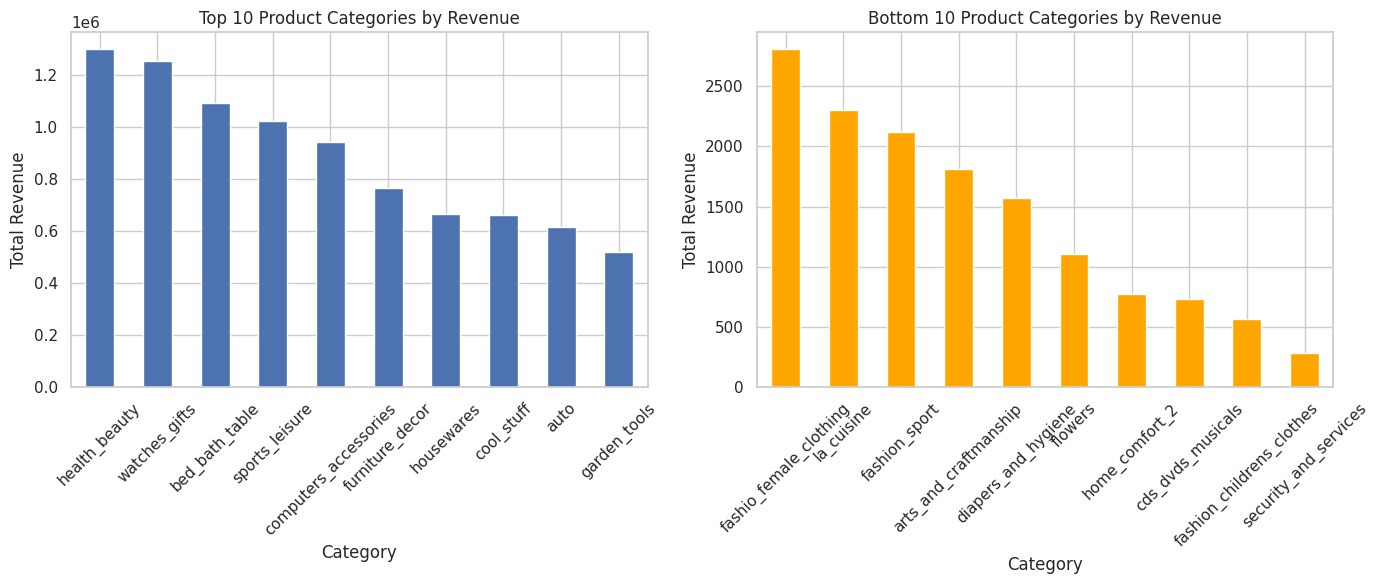

In [11]:
top_10 = revenue_category.head(10)
bottom_10 = revenue_category.tail(10)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
top_10.plot(kind='bar')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
bottom_10.plot(kind='bar', color='orange')
plt.title('Bottom 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

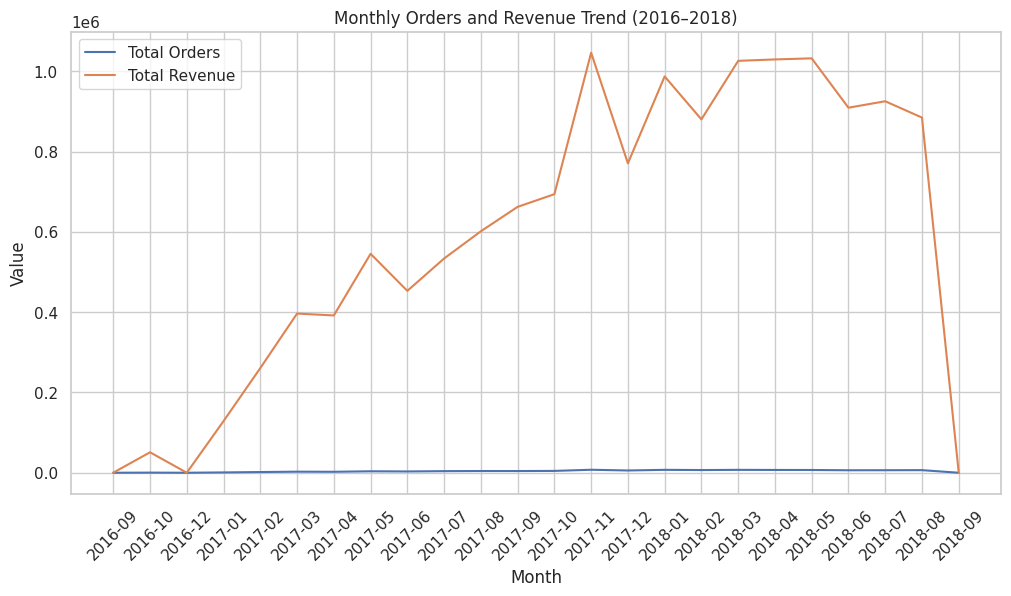

In [12]:
plt.figure(figsize=(12,6))

plt.plot(monthly_orders['month'], monthly_orders['total_orders'], label='Total Orders')

plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'], label='Total Revenue')

plt.title('Monthly Orders and Revenue Trend (2016–2018)')
plt.xlabel('Month')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()

plt.show()

**Insight:** (Opsional)
- Visualisasi digunakan untuk menunjukkan bahwa hanya beberapa kategori produk yang mendominasi total revenue, sementara sebagian besar kategori lainnya memiliki kontribusi yang jauh lebih rendah (Pertanyaan 1)
- Terdapat periode peningkatan yang signifikan yang kemungkinan dipengaruhi oleh faktor musiman atau promosi (Pertanyaan 2)

## Analisis Lanjutan (Opsional)

In [15]:
#Delivery Time
delivery_stats = df['delivery_time'].describe()
print(delivery_stats)

# Insight tambahan
avg_delivery = df['delivery_time'].mean()
max_delivery = df['delivery_time'].max()
min_delivery = df['delivery_time'].min()

print(f"Rata-rata delivery time: {avg_delivery:.2f} hari")
print(f"Delivery tercepat: {min_delivery} hari")
print(f"Delivery terlama: {max_delivery} hari\n")

#Payment Method
payment_dist = df['payment_type'].value_counts().reset_index()
payment_dist.columns = ['payment_type', 'count']

payment_dist

count    117601.000000
mean         13.585097
std          28.653042
min        -213.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         515.000000
Name: delivery_time, dtype: float64
Rata-rata delivery time: 13.59 hari
Delivery tercepat: -213 hari
Delivery terlama: 515 hari



,payment_type,count
0,credit_card,86769
1,boleto,22867
2,voucher,6274
3,debit_card,1691


## **Download File**

In [19]:
# Monthly Orders
monthly_orders.to_csv(os.path.join('/content/drive/MyDrive/Projek Analisis Data/Merge Data', 'monthly_orders.csv'), index=False)

# Monthly Revenue
monthly_revenue.to_csv(os.path.join('/content/drive/MyDrive/Projek Analisis Data/Merge Data', 'monthly_revenue.csv'), index=False)

# Top Category
revenue_category.reset_index().rename(columns={
    'product_category_name_english': 'category',
    'price': 'total_revenue'
}).to_csv(os.path.join('/content/drive/MyDrive/Projek Analisis Data/Merge Data', 'top_category.csv'), index=False)

# Payment Distribution
payment_dist.to_csv(os.path.join('/content/drive/MyDrive/Projek Analisis Data/Merge Data', 'payment_dist.csv'), index=False)

#Main Data
df.to_csv(os.path.join('/content/drive/MyDrive/Projek Analisis Data/Merge Data', 'main_data.csv'), index=False)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Analisis menunjukkan bahwa distribusi revenue antar kategori produk tidak merata, di mana hanya beberapa kategori yang mendominasi kontribusi total revenue.
Kategori-kategori dengan performa tinggi menjadi penyumbang utama pendapatan, sementara sebagian besar kategori lainnya memiliki kontribusi yang relatif rendah.

  Hal ini mengindikasikan adanya ketergantungan bisnis terhadap kategori tertentu, yang berpotensi menjadi risiko jika tidak diimbangi dengan diversifikasi produk.

- **Conclusion pertanyaan 2:** Tren bulanan menunjukkan bahwa jumlah order dan revenue mengalami fluktuasi sepanjang periode 2016–2018.
Terdapat beberapa periode dengan peningkatan signifikan yang kemungkinan dipengaruhi oleh faktor musiman atau aktivitas promosi.

  Namun, juga terdapat periode penurunan yang menunjukkan bahwa performa penjualan belum stabil secara konsisten dari waktu ke waktu.

**Rekomendasi Action Item:**
- Optimasi kategori produk
- Pengembangan kategori dengan performa rendah
- Strategi berbasis waktu
- Peningkatan kualitas data dan operasional
- Optimisasi metode pembayaran